# 03. Evaluación interna de diarización y relabeling — corregido

Este notebook revisa la consistencia interna de la diarización, el filtrado de segmentos, la selección de anchors y el relabeling.

Corrección principal: la sección de embeddings ya no asume que `all_anchor_embeddings.csv` contiene vectores. Ahora intenta leer primero los vectores guardados por el Notebook 01 corregido en `final_relabel/embedding_vectors_csv/all_anchor_embeddings_vectors.csv`. Si no existen, mantiene la opción de reconstruirlos y cachearlos explícitamente como columnas `emb_0000`, `emb_0001`, etc.

La evaluación definitiva de roles cliente-agente se realiza posteriormente con el proxy textual basado en transcripciones oficiales.


In [1]:
# =========================
# IMPORTS
# =========================

from pathlib import Path
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, clear_output

try:
    from google.cloud import storage
    GCS_AVAILABLE = True
except Exception:
    GCS_AVAILABLE = False

from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

print("Imports cargados correctamente.")


Imports cargados correctamente.


In [2]:
# =========================
# CONFIGURACIÓN
# =========================

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

DATA_DIR = PROJECT_DIR / "data"
EDA_DIR = DATA_DIR / "eda"
DIARIZATION_OUTPUT_DIR = DATA_DIR / "diarization_outputs"
FINAL_RELABEL_DIR = DIARIZATION_OUTPUT_DIR / "final_relabel"

# Carpeta creada por el Notebook 01 corregido para guardar embeddings vectoriales
EMBEDDING_VECTOR_DIR = FINAL_RELABEL_DIR / "embedding_vectors_csv"

GCS_DIARIZATION_OUTPUT_PREFIX = "gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/"

AUDIO_INVENTORY_PRIVATE_CSV = EDA_DIR / "audio_inventory_private.csv"

USE_GCS_IF_LOCAL_MISSING = True

RANDOM_SEED = 42
MAX_PAIRS_PER_IDENTITY = 20
MAX_NEGATIVE_PAIRS = 20000

MAX_OVERLAP_RATIO_FOR_VOICEPRINT = 0.05
MIN_DURATION_FOR_VOICEPRINT = 1.20
MIN_RMS_DBFS_FOR_VOICEPRINT = -40.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Configuración cargada.")
print(f"DIARIZATION_OUTPUT_DIR: {DIARIZATION_OUTPUT_DIR}")
print(f"FINAL_RELABEL_DIR: {FINAL_RELABEL_DIR}")
print(f"EMBEDDING_VECTOR_DIR: {EMBEDDING_VECTOR_DIR}")
print(f"AUDIO_INVENTORY_PRIVATE_CSV: {AUDIO_INVENTORY_PRIVATE_CSV}")


Configuración cargada.
DIARIZATION_OUTPUT_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs
FINAL_RELABEL_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel
EMBEDDING_VECTOR_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel/embedding_vectors_csv
AUDIO_INVENTORY_PRIVATE_CSV: /home/jupyter/TFM_ProcesadoDeAudios/data/eda/audio_inventory_private.csv


In [3]:
# =========================
# FUNCIONES AUXILIARES GCS / CARGA
# =========================

def split_gcs_uri(gcs_uri: str):
    if not gcs_uri.startswith("gs://"):
        raise ValueError("La ruta debe empezar por 'gs://'")
    path = gcs_uri[5:]
    bucket_name, _, prefix = path.partition("/")
    return bucket_name, prefix


def download_gcs_file_if_needed(gcs_uri: str, local_path: Path, overwrite: bool = False):
    if local_path.exists() and not overwrite:
        return local_path

    if not GCS_AVAILABLE:
        raise ImportError("google-cloud-storage no está disponible en este entorno.")

    local_path.parent.mkdir(parents=True, exist_ok=True)

    bucket_name, blob_path = split_gcs_uri(gcs_uri)
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_path)

    if not blob.exists():
        raise FileNotFoundError(f"No existe en GCS: {gcs_uri}")

    blob.download_to_filename(str(local_path))
    return local_path


def load_csv_with_optional_gcs(local_path: Path, gcs_relative_path: str = None):
    if local_path.exists():
        return pd.read_csv(local_path)

    if USE_GCS_IF_LOCAL_MISSING and gcs_relative_path is not None:
        gcs_uri = GCS_DIARIZATION_OUTPUT_PREFIX.rstrip("/") + "/" + gcs_relative_path.lstrip("/")
        download_gcs_file_if_needed(gcs_uri, local_path)
        return pd.read_csv(local_path)

    raise FileNotFoundError(f"No se encontró el CSV local: {local_path}")


def parse_audio_identity(audio_file_or_stem):
    name = str(audio_file_or_stem)
    stem = Path(name).stem

    m = re.match(r"^(raw_bajas|raw)_([0-9]+)(?:_clean)?$", stem)
    if m:
        return m.group(1), m.group(2)

    m = re.match(r"^([0-9]+)(?:_clean)?$", stem)
    if m:
        return np.nan, m.group(1)

    m = re.search(r"([0-9]{10,})", stem)
    if m:
        source = "raw_bajas" if "raw_bajas" in stem else ("raw" if "raw_" in stem else np.nan)
        return source, m.group(1)

    return np.nan, np.nan


def add_audio_keys(df, audio_col_candidates=("audio_file", "audio_stem", "audio_base", "file_stem", "filename")):
    df = df.copy()
    audio_col = None
    for col in audio_col_candidates:
        if col in df.columns:
            audio_col = col
            break

    if audio_col is None:
        return df

    parsed = df[audio_col].apply(parse_audio_identity)
    df["source_dataset_parsed"] = parsed.apply(lambda x: x[0])
    df["audio_id_parsed"] = parsed.apply(lambda x: x[1]).astype("string")
    return df


print("Funciones auxiliares listas.")


Funciones auxiliares listas.


## 1. Carga de outputs de diarización y relabeling

In [4]:
# =========================
# CARGA DE OUTPUTS PRINCIPALES
# =========================

SUMMARY_CSV = DIARIZATION_OUTPUT_DIR / "diarization_summary.csv"
ALL_SCORED_CSV = DIARIZATION_OUTPUT_DIR / "diarization_all_scored_segments.csv"
ALL_VALID_CSV = DIARIZATION_OUTPUT_DIR / "diarization_all_valid_segments.csv"
ALL_ANCHORS_CSV = DIARIZATION_OUTPUT_DIR / "diarization_all_anchor_segments.csv"

FINAL_SEGMENTS_CSV = FINAL_RELABEL_DIR / "all_final_segments.csv"
FINAL_MERGED_CSV = FINAL_RELABEL_DIR / "all_final_merged_segments.csv"
CHANGED_SEGMENTS_CSV = FINAL_RELABEL_DIR / "all_changed_segments.csv"
RELABEL_SUMMARY_CSV = FINAL_RELABEL_DIR / "relabel_summary.csv"
ANCHOR_EMBEDDINGS_CSV = FINAL_RELABEL_DIR / "all_anchor_embeddings.csv"

df_summary = load_csv_with_optional_gcs(SUMMARY_CSV, "diarization_summary.csv")
df_all_scored_segments = load_csv_with_optional_gcs(ALL_SCORED_CSV, "diarization_all_scored_segments.csv")
df_all_valid_segments = load_csv_with_optional_gcs(ALL_VALID_CSV, "diarization_all_valid_segments.csv")
df_all_anchor_segments = load_csv_with_optional_gcs(ALL_ANCHORS_CSV, "diarization_all_anchor_segments.csv")

try:
    df_final_segments = load_csv_with_optional_gcs(FINAL_SEGMENTS_CSV, "final_relabel/all_final_segments.csv")
except Exception as e:
    df_final_segments = pd.DataFrame()
    print(f"No se pudo cargar all_final_segments.csv: {e}")

try:
    df_final_merged_segments = load_csv_with_optional_gcs(FINAL_MERGED_CSV, "final_relabel/all_final_merged_segments.csv")
except Exception as e:
    df_final_merged_segments = pd.DataFrame()
    print(f"No se pudo cargar all_final_merged_segments.csv: {e}")

try:
    df_changed_segments = load_csv_with_optional_gcs(CHANGED_SEGMENTS_CSV, "final_relabel/all_changed_segments.csv")
except Exception as e:
    df_changed_segments = pd.DataFrame()
    print(f"No se pudo cargar all_changed_segments.csv: {e}")

try:
    df_relabel_summary = load_csv_with_optional_gcs(RELABEL_SUMMARY_CSV, "final_relabel/relabel_summary.csv")
except Exception as e:
    df_relabel_summary = pd.DataFrame()
    print(f"No se pudo cargar relabel_summary.csv: {e}")

try:
    df_anchor_embeddings = load_csv_with_optional_gcs(ANCHOR_EMBEDDINGS_CSV, "final_relabel/all_anchor_embeddings.csv")
except Exception as e:
    df_anchor_embeddings = pd.DataFrame()
    print(f"No se pudo cargar all_anchor_embeddings.csv: {e}")

print("Carga finalizada.")
print(f"Audios en summary: {len(df_summary)}")
print(f"Segmentos puntuados: {len(df_all_scored_segments)}")
print(f"Segmentos válidos: {len(df_all_valid_segments)}")
print(f"Anchors: {len(df_all_anchor_segments)}")
print(f"Segmentos finales relabel: {len(df_final_segments)}")
print(f"Embeddings de anchors: {len(df_anchor_embeddings)}")


Carga finalizada.
Audios en summary: 1198
Segmentos puntuados: 73000
Segmentos válidos: 43867
Anchors: 7038
Segmentos finales relabel: 43493
Embeddings de anchors: 7038


In [5]:
# =========================
# CARGA DE INVENTARIO / METADATA
# =========================

if AUDIO_INVENTORY_PRIVATE_CSV.exists():
    df_inventory = pd.read_csv(AUDIO_INVENTORY_PRIVATE_CSV)
    print("Inventario cargado.")
    print(df_inventory.shape)
else:
    df_inventory = pd.DataFrame()
    print("No se encontró inventario privado local. Se continuará sin metadata de customer/agent.")

if not df_inventory.empty:
    for col in ["source_dataset", "audio_id"]:
        if col in df_inventory.columns:
            df_inventory[col] = df_inventory[col].astype(str).str.strip()

    keep_cols = [
        "source_dataset", "audio_id",
        "audio_hash", "customer_hash", "agent_hash",
        "customer_id", "agent_id",
        "brand_ds", "duration_seconds", "silence_ratio", "nonsilent_ratio"
    ]
    keep_cols = [c for c in keep_cols if c in df_inventory.columns]
    df_inventory_small = df_inventory[keep_cols].drop_duplicates(["source_dataset", "audio_id"], keep="first").copy()
else:
    df_inventory_small = pd.DataFrame()


Inventario cargado.
(1200, 36)


In [6]:
# =========================
# AÑADIR CLAVES DE AUDIO Y METADATA A TABLAS
# =========================

tables_to_key = {
    "summary": df_summary,
    "scored": df_all_scored_segments,
    "valid": df_all_valid_segments,
    "anchors": df_all_anchor_segments,
    "final": df_final_segments,
    "final_merged": df_final_merged_segments,
    "changed": df_changed_segments,
    "anchor_embeddings": df_anchor_embeddings,
}

for name, df in tables_to_key.items():
    if df is not None and not df.empty:
        tables_to_key[name] = add_audio_keys(df)

df_summary = tables_to_key["summary"]
df_all_scored_segments = tables_to_key["scored"]
df_all_valid_segments = tables_to_key["valid"]
df_all_anchor_segments = tables_to_key["anchors"]
df_final_segments = tables_to_key["final"]
df_final_merged_segments = tables_to_key["final_merged"]
df_changed_segments = tables_to_key["changed"]
df_anchor_embeddings = tables_to_key["anchor_embeddings"]

def merge_metadata(df):
    if df is None or df.empty or df_inventory_small.empty:
        return df

    if "source_dataset_parsed" not in df.columns or "audio_id_parsed" not in df.columns:
        return df

    out = df.merge(
        df_inventory_small,
        left_on=["source_dataset_parsed", "audio_id_parsed"],
        right_on=["source_dataset", "audio_id"],
        how="left",
        suffixes=("", "_inventory")
    )
    return out

df_summary_meta = merge_metadata(df_summary)
df_all_scored_segments_meta = merge_metadata(df_all_scored_segments)
df_all_valid_segments_meta = merge_metadata(df_all_valid_segments)
df_all_anchor_segments_meta = merge_metadata(df_all_anchor_segments)
df_final_segments_meta = merge_metadata(df_final_segments)
df_anchor_embeddings_meta = merge_metadata(df_anchor_embeddings)

print("Metadata integrada cuando estuvo disponible.")


Metadata integrada cuando estuvo disponible.


## 2. Métricas internas de diarización

Estas métricas no miden DER formal, pero ayudan a detectar problemas estructurales: audios sin dos hablantes, exceso de microsegmentación, pocos segmentos válidos, exceso de overlap o ausencia de anchors.


In [7]:
# =========================
# RESUMEN GLOBAL
# =========================

summary_rows = {
    "n_audios_summary": len(df_summary),
    "n_scored_segments": len(df_all_scored_segments),
    "n_valid_segments": len(df_all_valid_segments),
    "n_anchor_segments": len(df_all_anchor_segments),
    "n_final_segments": len(df_final_segments),
    "n_changed_segments": len(df_changed_segments),
}

pd.DataFrame([summary_rows])


,n_audios_summary,n_scored_segments,n_valid_segments,n_anchor_segments,n_final_segments,n_changed_segments
0,1198,73000,43867,7038,43493,3700


In [8]:
# =========================
# SPEAKERS DETECTADOS POR AUDIO
# =========================

if "n_speakers" in df_summary.columns:
    display(
        df_summary["n_speakers"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("n_speakers")
        .reset_index(name="n_audios")
    )

    pct_two_speakers = (df_summary["n_speakers"] == 2).mean()
    print(f"Porcentaje de audios con 2 speakers detectados: {pct_two_speakers:.2%}")
else:
    print("No existe columna n_speakers en df_summary.")


,n_speakers,n_audios
0,2,1198


Porcentaje de audios con 2 speakers detectados: 100.00%


,count,mean,std,min,25%,50%,75%,max
n_regular_segments,1198.0,78.482471,27.138451,21.0,59.0,75.0,96.0,211.0
n_scored_segments,1198.0,60.934891,23.205430,16.0,45.0,57.0,73.0,199.0
n_valid_segments,1198.0,36.616861,12.400755,7.0,27.0,36.0,45.0,100.0
n_anchor_segments,1198.0,5.874791,0.496621,2.0,6.0,6.0,6.0,6.0
n_overlap_regions,1198.0,13.732888,9.571807,0.0,7.0,11.5,18.0,68.0


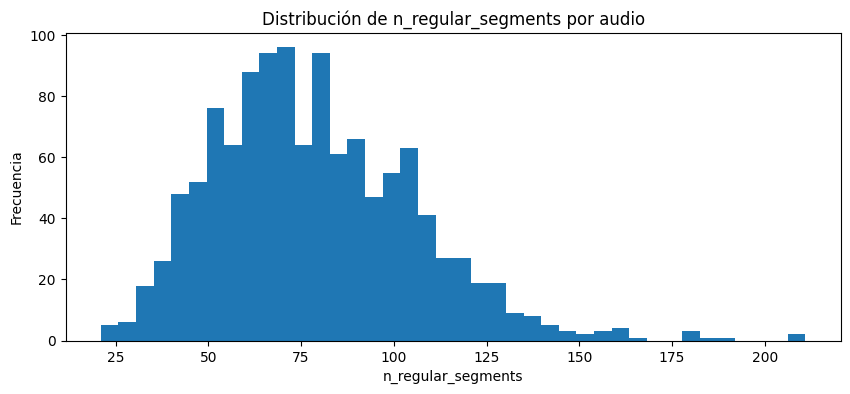

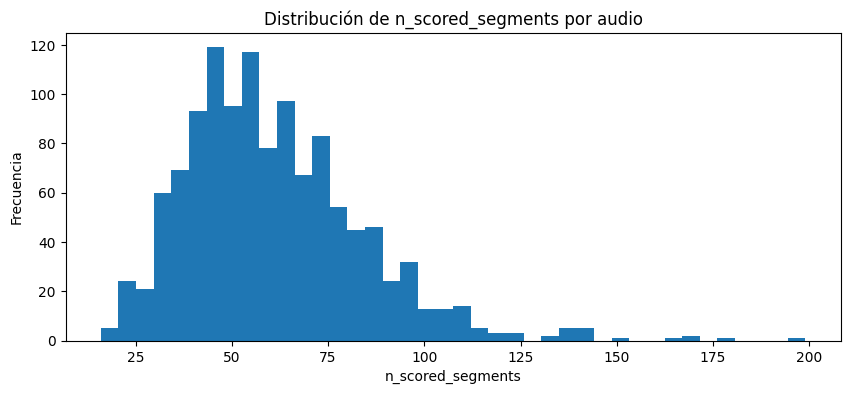

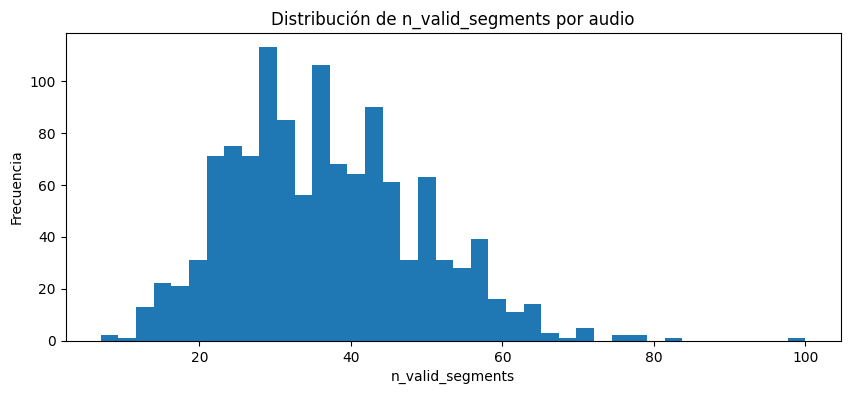

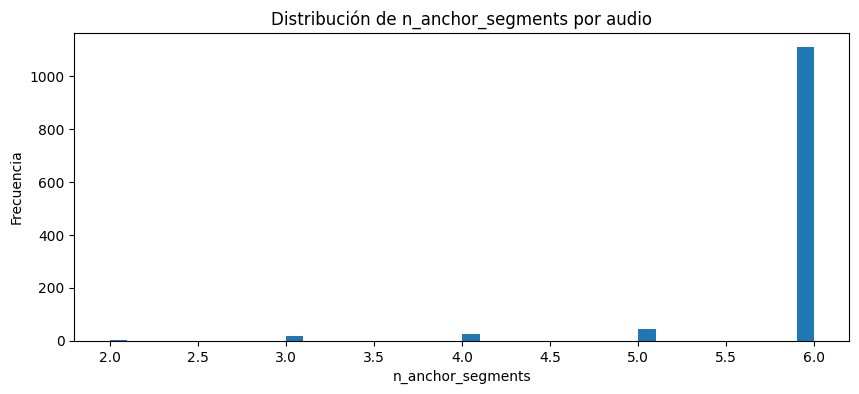

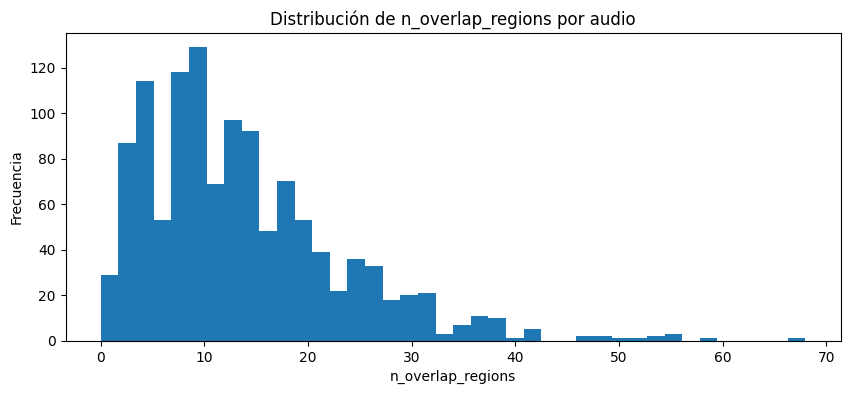

In [9]:
# =========================
# SEGMENTOS POR AUDIO
# =========================

cols = [
    "n_regular_segments",
    "n_scored_segments",
    "n_valid_segments",
    "n_anchor_segments",
    "n_overlap_regions"
]
cols = [c for c in cols if c in df_summary.columns]

if cols:
    display(df_summary[cols].describe().T)

    for col in cols:
        plt.figure(figsize=(10, 4))
        plt.hist(df_summary[col].dropna(), bins=40)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.title(f"Distribución de {col} por audio")
        plt.show()
else:
    print("No se encontraron columnas de conteo de segmentos en df_summary.")


,count,mean,std,min,25%,50%,75%,max
valid_segment_ratio,1198.0,0.616178,0.105948,0.164384,0.54717,0.622222,0.688889,0.916667
anchor_segment_ratio,1198.0,0.110328,0.043056,0.027273,0.08000,0.103448,0.130435,0.352941


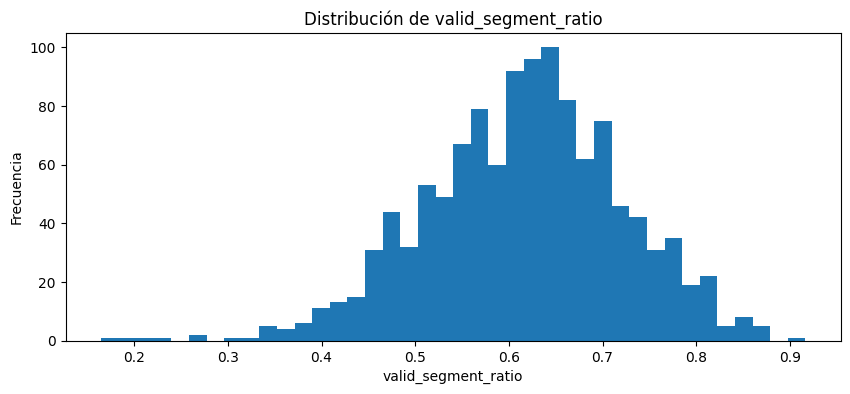

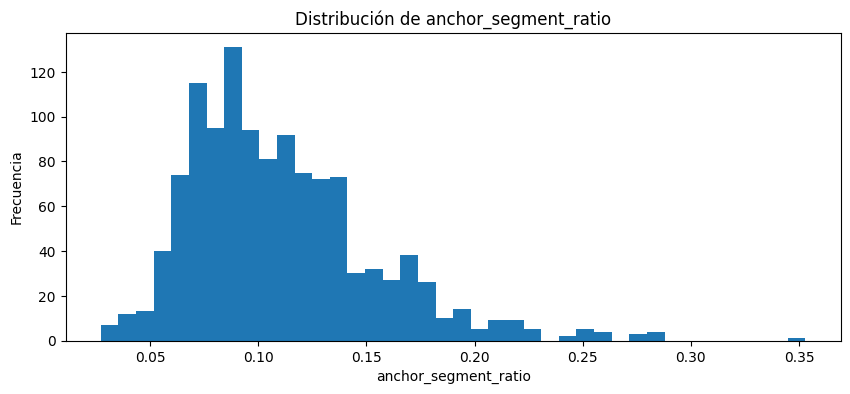

In [10]:
# =========================
# RATIO DE SEGMENTOS VÁLIDOS Y ANCHORS
# =========================

df_quality_audio = df_summary.copy()

if "n_scored_segments" in df_quality_audio.columns and "n_valid_segments" in df_quality_audio.columns:
    df_quality_audio["valid_segment_ratio"] = (
        df_quality_audio["n_valid_segments"] / df_quality_audio["n_scored_segments"].replace(0, np.nan)
    )

if "n_scored_segments" in df_quality_audio.columns and "n_anchor_segments" in df_quality_audio.columns:
    df_quality_audio["anchor_segment_ratio"] = (
        df_quality_audio["n_anchor_segments"] / df_quality_audio["n_scored_segments"].replace(0, np.nan)
    )

display_cols = [c for c in ["valid_segment_ratio", "anchor_segment_ratio"] if c in df_quality_audio.columns]
if display_cols:
    display(df_quality_audio[display_cols].describe().T)

    for col in display_cols:
        plt.figure(figsize=(10, 4))
        plt.hist(df_quality_audio[col].dropna(), bins=40)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.title(f"Distribución de {col}")
        plt.show()


## 3. Calidad de segmentos y overlap

Aquí se revisa si los segmentos que quedan para relabeling y huella son suficientemente largos, energéticos y poco contaminados por overlap.


count    73000.000000
mean         0.138958
std          0.301492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.063291
max          1.000000
Name: overlap_ratio, dtype: float64


,threshold,n_segments_leq,pct_segments_leq,n_segments_gt,pct_segments_gt
0,0.00,48208,0.660384,24792,0.339616
1,0.01,49506,0.678164,23494,0.321836
2,0.03,51970,0.711918,21030,0.288082
3,0.05,53777,0.736671,19223,0.263329
4,0.10,56865,0.778973,16135,0.221027
5,0.15,58817,0.805712,14183,0.194288
6,0.20,60269,0.825603,12731,0.174397
7,0.30,62026,0.849671,10974,0.150329


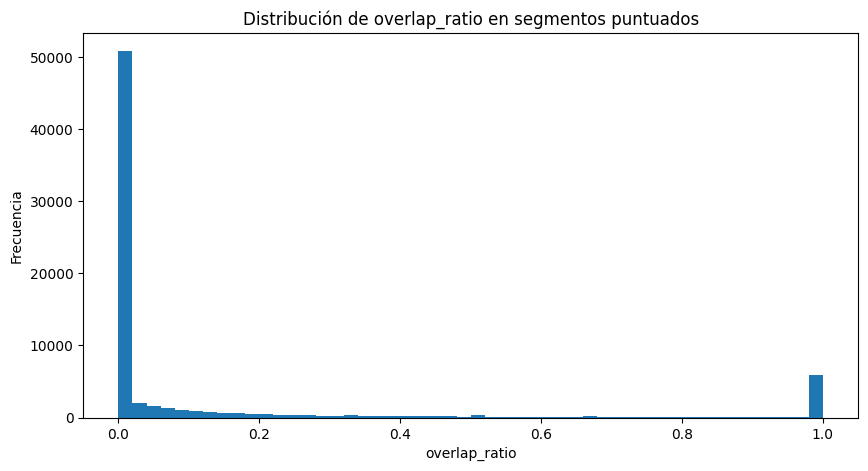

In [11]:
# =========================
# DISTRIBUCIÓN DE OVERLAP EN SEGMENTOS PUNTUADOS
# =========================

if "overlap_ratio" in df_all_scored_segments.columns:
    print(df_all_scored_segments["overlap_ratio"].describe())

    thresholds = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]
    rows = []
    for t in thresholds:
        rows.append({
            "threshold": t,
            "n_segments_leq": (df_all_scored_segments["overlap_ratio"] <= t).sum(),
            "pct_segments_leq": (df_all_scored_segments["overlap_ratio"] <= t).mean(),
            "n_segments_gt": (df_all_scored_segments["overlap_ratio"] > t).sum(),
            "pct_segments_gt": (df_all_scored_segments["overlap_ratio"] > t).mean(),
        })

    df_overlap_threshold_summary = pd.DataFrame(rows)
    display(df_overlap_threshold_summary)

    plt.figure(figsize=(10, 5))
    plt.hist(df_all_scored_segments["overlap_ratio"].dropna(), bins=50)
    plt.xlabel("overlap_ratio")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de overlap_ratio en segmentos puntuados")
    plt.show()
else:
    print("No existe overlap_ratio en df_all_scored_segments.")


In [12]:
# =========================
# SEGMENTOS CANDIDATOS PARA HUELLA DE VOZ
# =========================

df_base_for_voiceprint = df_final_segments_meta if not df_final_segments_meta.empty else df_all_valid_segments_meta

required_cols = ["duration", "overlap_ratio", "rms_dbfs"]
missing = [c for c in required_cols if c not in df_base_for_voiceprint.columns]

if missing:
    print(f"No se puede aplicar filtro completo. Faltan columnas: {missing}")
    df_voiceprint_segments = pd.DataFrame()
else:
    speaker_label_col = "speaker_final" if "speaker_final" in df_base_for_voiceprint.columns else "speaker"

    df_voiceprint_segments = df_base_for_voiceprint[
        (df_base_for_voiceprint["duration"] >= MIN_DURATION_FOR_VOICEPRINT) &
        (df_base_for_voiceprint["overlap_ratio"] <= MAX_OVERLAP_RATIO_FOR_VOICEPRINT) &
        (df_base_for_voiceprint["rms_dbfs"] >= MIN_RMS_DBFS_FOR_VOICEPRINT) &
        (df_base_for_voiceprint[speaker_label_col].notna())
    ].copy()

    print(f"Segmentos base: {len(df_base_for_voiceprint)}")
    print(f"Segmentos candidatos para huella: {len(df_voiceprint_segments)}")
    print(f"Porcentaje conservado: {len(df_voiceprint_segments) / len(df_base_for_voiceprint):.2%}")

    display(df_voiceprint_segments[["audio_file", speaker_label_col, "duration", "overlap_ratio", "rms_dbfs"]].head())


Segmentos base: 43493
Segmentos candidatos para huella: 27853
Porcentaje conservado: 64.04%


,audio_file,speaker_final,duration,overlap_ratio,rms_dbfs
0,raw_9154117451310006851_clean.wav,SPEAKER_01,4.421250,0.000000,-28.919975
2,raw_9154117451310006851_clean.wav,SPEAKER_01,7.374375,0.000000,-29.186810
4,raw_9154117451310006851_clean.wav,SPEAKER_01,4.708125,0.000000,-27.753717
9,raw_9154117451310006851_clean.wav,SPEAKER_01,2.143125,0.000000,-26.843788
11,raw_9154117451310006851_clean.wav,SPEAKER_00,2.649375,0.012739,-32.090672


## 4. Análisis de relabeling

Se revisa qué porcentaje de segmentos cambió de hablante y con qué margen de confianza. Esto permite saber si el relabeling actúa como una corrección puntual o si está cambiando masivamente la diarización.


In [13]:
# =========================
# RESUMEN DE RELABELING
# =========================

if not df_final_segments.empty and "speaker_original" in df_final_segments.columns and "speaker_final" in df_final_segments.columns:
    df_tmp = df_final_segments.copy()
    df_tmp["was_relabelled"] = df_tmp["speaker_original"] != df_tmp["speaker_final"]

    print(f"Total segmentos finales: {len(df_tmp)}")
    print(f"Segmentos relabelados: {df_tmp['was_relabelled'].sum()}")
    print(f"Porcentaje relabelado: {df_tmp['was_relabelled'].mean():.2%}")

    display(
        df_tmp["was_relabelled"]
        .value_counts(dropna=False)
        .rename_axis("was_relabelled")
        .reset_index(name="n_segments")
    )
else:
    print("No hay columnas speaker_original/speaker_final o no se cargó df_final_segments.")


Total segmentos finales: 43493
Segmentos relabelados: 3700
Porcentaje relabelado: 8.51%


,was_relabelled,n_segments
0,False,39793
1,True,3700


Columna de margen: distance_margin
count    43493.000000
mean         0.346742
std          0.187290
min          0.000003
25%          0.200045
50%          0.345564
75%          0.487432
max          0.930874
Name: distance_margin, dtype: float64


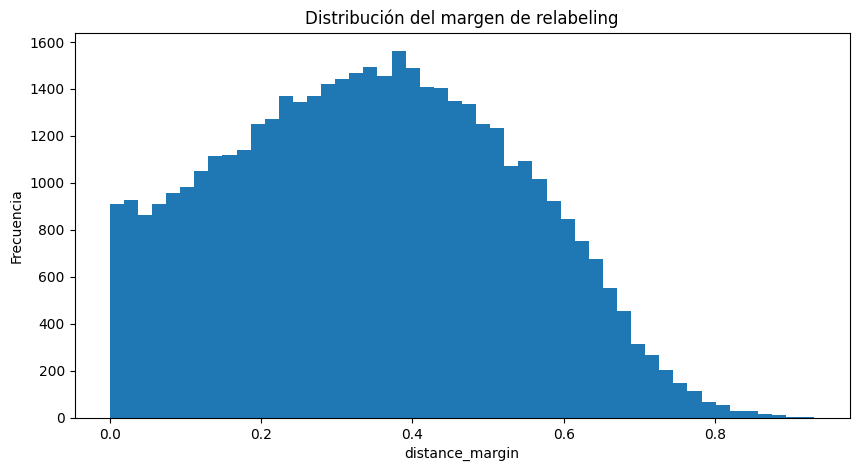


Margen en segmentos que cambiaron:
count    3700.000000
mean        0.152579
std         0.116822
min         0.010009
25%         0.058762
50%         0.121720
75%         0.222748
max         0.698415
Name: distance_margin, dtype: float64


In [14]:
# =========================
# DISTRIBUCIÓN DE MARGEN DE RELABELING
# =========================

margin_col = None
for c in ["distance_margin", "similarity_margin", "margin", "cosine_margin", "relabel_margin"]:
    if not df_final_segments.empty and c in df_final_segments.columns:
        margin_col = c
        break

if margin_col is not None:
    print(f"Columna de margen: {margin_col}")
    print(df_final_segments[margin_col].describe())

    plt.figure(figsize=(10, 5))
    plt.hist(df_final_segments[margin_col].dropna(), bins=50)
    plt.xlabel(margin_col)
    plt.ylabel("Frecuencia")
    plt.title("Distribución del margen de relabeling")
    plt.show()

    if not df_changed_segments.empty and margin_col in df_changed_segments.columns:
        print("\nMargen en segmentos que cambiaron:")
        print(df_changed_segments[margin_col].describe())
else:
    print("No se encontró columna de margen en df_final_segments.")



## 5. Embeddings de anchors: diagnóstico y carga vectorial

En el Notebook 01, los embeddings se calcularon para construir centroides y ejecutar el relabeling. El CSV `all_anchor_embeddings.csv` puede contener únicamente metadata de anchors, sin el vector completo. Por eso, esta sección intenta leer los embeddings vectoriales guardados por el Notebook 01 corregido en:

`final_relabel/embedding_vectors_csv/all_anchor_embeddings_vectors.csv`

Si ese archivo todavía no existe, se mantiene la opción de reconstruir los embeddings desde los anchors y los audios limpios activando `REBUILD_ANCHOR_EMBEDDINGS = True`.


In [15]:

# =========================
# DIAGNÓSTICO Y CARGA DE EMBEDDINGS VECTORIALES
# =========================

from pathlib import Path
import os
import json
import math
import numpy as np
import pandas as pd

# Ruta correcta creada por el Notebook 01 corregido
EMBEDDING_VECTOR_DIR = FINAL_RELABEL_DIR / "embedding_vectors_csv"

# Archivo global esperado con embeddings de anchors
EMBEDDING_VECTOR_CACHE_CSV = EMBEDDING_VECTOR_DIR / "all_anchor_embeddings_vectors.csv"

# Ruta legacy, por si existiera una versión anterior fuera de la carpeta embedding_vectors_csv
LEGACY_EMBEDDING_VECTOR_CACHE_CSV = FINAL_RELABEL_DIR / "all_anchor_embeddings_vectors.csv"

# Por defecto no reconstruye embeddings para evitar una ejecución pesada accidental.
# Cambiar a True solo si se desea regenerar el CSV vectorial desde los audios.
REBUILD_ANCHOR_EMBEDDINGS = False
MAX_ANCHORS_TO_REBUILD = None  # None = todos; usar número pequeño para prueba, ej. 200


def detect_embedding_columns(df):
    """Detecta columnas vectoriales explícitas de embeddings."""
    if df is None or df.empty:
        return []

    prefix_candidates = ["emb_", "embedding_", "dim_", "xvector_", "ecapa_"]
    for prefix in prefix_candidates:
        cols = [c for c in df.columns if str(c).startswith(prefix)]
        if len(cols) >= 16:
            return cols

    # Evitar confundir métricas acústicas / conteos con dimensiones de embedding.
    known_numeric_not_embedding = {
        "start", "end", "duration", "rms_dbfs", "overlap_duration_sec",
        "overlap_ratio", "segment_id_raw", "anchor_rank",
        "duration_sec", "n_speakers", "n_regular_segments", "n_scored_segments",
        "n_valid_segments", "n_anchor_segments", "n_overlap_regions",
        "best_distance", "second_distance", "distance_margin",
        "dist_SPEAKER_00", "dist_SPEAKER_01"
    }

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in known_numeric_not_embedding]

    # Solo aceptamos fallback numérico si hay muchas columnas; aun así se imprime diagnóstico.
    if len(numeric_cols) >= 32:
        return numeric_cols

    return []


def load_embedding_vector_cache():
    """Carga el CSV vectorial de anchors desde la nueva carpeta o desde una ruta legacy."""
    candidate_paths = [
        EMBEDDING_VECTOR_CACHE_CSV,
        LEGACY_EMBEDDING_VECTOR_CACHE_CSV,
    ]

    for path in candidate_paths:
        if path.exists():
            print("Cargando embeddings vectoriales desde:")
            print(path)
            df = pd.read_csv(path)
            df = add_audio_keys(df)
            return df, path

    return pd.DataFrame(), None


# 1) Intentar detectar embeddings en el CSV cargado originalmente.
# Normalmente all_anchor_embeddings.csv solo tendrá metadata, pero se deja este paso por compatibilidad.
embedding_cols = detect_embedding_columns(df_anchor_embeddings_meta)
print("Columnas vectoriales detectadas en df_anchor_embeddings_meta:", len(embedding_cols))

if len(embedding_cols) > 0:
    print("Se detectaron vectores directamente en df_anchor_embeddings_meta.")
    df_anchor_embeddings_vectors = df_anchor_embeddings_meta.copy()
    df_anchor_embeddings_vectors_meta = df_anchor_embeddings_meta.copy()
else:
    # 2) Si no hay, cargar el archivo vectorial generado por el Notebook 01 corregido.
    df_anchor_embeddings_vectors, embedding_cache_path_used = load_embedding_vector_cache()

    if not df_anchor_embeddings_vectors.empty:
        df_anchor_embeddings_vectors_meta = merge_metadata(df_anchor_embeddings_vectors)
        embedding_cols = detect_embedding_columns(df_anchor_embeddings_vectors_meta)
        print("Columnas vectoriales detectadas en cache:", len(embedding_cols))
    else:
        df_anchor_embeddings_vectors_meta = pd.DataFrame()
        embedding_cache_path_used = None

# 3) Diagnóstico claro si sigue sin haber vectores.
if len(embedding_cols) == 0:
    print("\nNo se detectaron columnas vectoriales de embeddings.")
    print("Esto NO significa que el relabeling no haya usado embeddings.")
    print("Significa que todavía no se encontró el CSV vectorial esperado:")
    print(EMBEDDING_VECTOR_CACHE_CSV)
    print("\nVerifica que haya terminado el Notebook 01 corregido y que exista la carpeta:")
    print(EMBEDDING_VECTOR_DIR)
    print("\nSi todavía no existe, cambia REBUILD_ANCHOR_EMBEDDINGS = True y vuelve a correr esta sección.")
else:
    print("\nEmbeddings vectoriales disponibles.")
    print("Filas con embeddings:", len(df_anchor_embeddings_vectors_meta))
    print("Dimensión del embedding:", len(embedding_cols))
    print("Primeras columnas:", embedding_cols[:10])

    # Mostrar una muestra sin imprimir todas las dimensiones
    meta_cols = [
        c for c in [
            "audio_file", "audio_stem", "audio_base", "start", "end", "duration",
            "speaker_final", "speaker", "anchor_rank",
            "source_dataset_parsed", "audio_id_parsed", "customer_hash", "agent_hash"
        ]
        if c in df_anchor_embeddings_vectors_meta.columns
    ]
    display(df_anchor_embeddings_vectors_meta[meta_cols + embedding_cols[:5]].head())


Columnas vectoriales detectadas en df_anchor_embeddings_meta: 0
Cargando embeddings vectoriales desde:
/home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel/embedding_vectors_csv/all_anchor_embeddings_vectors.csv
Columnas vectoriales detectadas en cache: 256

Embeddings vectoriales disponibles.
Filas con embeddings: 7038
Dimensión del embedding: 256
Primeras columnas: ['emb_0000', 'emb_0001', 'emb_0002', 'emb_0003', 'emb_0004', 'emb_0005', 'emb_0006', 'emb_0007', 'emb_0008', 'emb_0009']


,audio_file,audio_stem,start,end,duration,speaker,anchor_rank,source_dataset_parsed,audio_id_parsed,customer_hash,agent_hash,emb_0000,emb_0001,emb_0002,emb_0003,emb_0004
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,120.147219,123.555969,3.408750,SPEAKER_00,1,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.027094,0.026547,0.075299,0.026105,0.036727
1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,72.171594,75.360969,3.189375,SPEAKER_00,2,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,0.043530,-0.042951,0.077997,-0.022896,0.054396
2,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,124.230969,127.285344,3.054375,SPEAKER_00,3,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.066450,-0.047798,-0.014950,0.040734,-0.009607
3,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,94.564719,102.951594,8.386875,SPEAKER_01,1,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.102441,-0.030891,0.033558,-0.017700,0.062358
4,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,6.426594,13.800969,7.374375,SPEAKER_01,2,raw,9154117451310006851,a9caf51c656e2261,143be6589a2896d9,-0.096318,-0.057578,0.002733,-0.012004,0.039952


In [16]:

# =========================
# RECONSTRUCCIÓN OPCIONAL DE EMBEDDINGS DE ANCHORS
# =========================

if REBUILD_ANCHOR_EMBEDDINGS and len(embedding_cols) == 0:
    import torch
    import torchaudio
    import soundfile as sf
    from pyannote.audio.pipelines.speaker_verification import PretrainedSpeakerEmbedding

    CLEAN_AUDIO_DIR = DATA_DIR / "clean_audios"
    GCS_CLEAN_AUDIO_PREFIX = "gs://catedras_audio_detection/pipelineA/procesados_UNAV/clean_audios/"

    EMBEDDING_MODEL_ID = "pyannote/wespeaker-voxceleb-resnet34-LM"
    EMBEDDING_SAMPLE_RATE = 16000
    HF_TOKEN = os.environ.get("HF_TOKEN", None)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    embedding_model = PretrainedSpeakerEmbedding(
        EMBEDDING_MODEL_ID,
        device=device,
        token=HF_TOKEN
    )

    print("Modelo de embeddings cargado:", EMBEDDING_MODEL_ID)
    print("Device:", device)

    def l2_normalize(vec):
        vec = np.asarray(vec, dtype=np.float32).reshape(-1)
        norm = np.linalg.norm(vec)
        if norm <= 1e-12:
            return vec
        return vec / norm

    def resolve_clean_audio_path(audio_file):
        """Busca el audio limpio localmente y, si falta, intenta descargarlo de GCS."""
        audio_file = str(audio_file)
        stem = Path(audio_file).stem
        suffix = Path(audio_file).suffix or ".wav"

        candidate_names = []
        for s in [stem, stem.replace("pipelineA_", "")]:
            candidate_names.append(s + suffix)
            if not s.endswith("_clean"):
                candidate_names.append(s + "_clean" + suffix)

        # Añadir búsqueda por ID numérico, útil si cambian prefijos.
        m = re.search(r"([0-9]{10,})", stem)
        if m:
            audio_id = m.group(1)
            candidate_names.extend([
                f"raw_{audio_id}_clean.wav",
                f"raw_bajas_{audio_id}_clean.wav",
                f"pipelineA_raw_{audio_id}_clean.wav",
                f"pipelineA_raw_bajas_{audio_id}_clean.wav",
            ])

        # Quitar duplicados preservando orden.
        seen = set()
        candidate_names = [x for x in candidate_names if not (x in seen or seen.add(x))]

        for name in candidate_names:
            p = CLEAN_AUDIO_DIR / name
            if p.exists():
                return p

        # Intentar descarga directa desde GCS si existe cliente disponible.
        if USE_GCS_IF_LOCAL_MISSING and GCS_AVAILABLE:
            for name in candidate_names:
                try:
                    gcs_uri = GCS_CLEAN_AUDIO_PREFIX.rstrip("/") + "/" + name
                    local_path = CLEAN_AUDIO_DIR / name
                    download_gcs_file_if_needed(gcs_uri, local_path, overwrite=False)
                    if local_path.exists():
                        return local_path
                except Exception:
                    pass

        return None

    def load_audio_mono(path):
        audio, sr = sf.read(str(path), always_2d=False)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        return audio.astype(np.float32), int(sr)

    def get_segment_embedding(audio_mono, sr, start, end):
        start_sample = max(0, int(round(float(start) * sr)))
        end_sample = min(len(audio_mono), int(round(float(end) * sr)))
        if end_sample <= start_sample:
            return None

        segment_audio = audio_mono[start_sample:end_sample]
        if len(segment_audio) == 0:
            return None

        waveform = torch.from_numpy(segment_audio).float().unsqueeze(0).unsqueeze(0)
        if sr != EMBEDDING_SAMPLE_RATE:
            waveform = torchaudio.functional.resample(waveform, sr, EMBEDDING_SAMPLE_RATE)

        with torch.no_grad():
            emb = embedding_model(waveform)

        emb = np.asarray(emb).reshape(-1)
        if not np.all(np.isfinite(emb)):
            return None
        return l2_normalize(emb)

    # Usar como base los anchors metadata guardados por Notebook 01.
    # Si estuviera vacío, caer al CSV global de anchors.
    df_anchor_source = df_anchor_embeddings_meta if not df_anchor_embeddings_meta.empty else df_all_anchor_segments_meta
    df_anchor_source = df_anchor_source.copy()

    if MAX_ANCHORS_TO_REBUILD is not None:
        df_anchor_source = df_anchor_source.head(int(MAX_ANCHORS_TO_REBUILD)).copy()

    required = {"audio_file", "start", "end"}
    missing = required - set(df_anchor_source.columns)
    if missing:
        raise ValueError(f"Faltan columnas para reconstruir embeddings: {missing}")

    rows = []
    audio_cache = {}

    for idx, row in df_anchor_source.reset_index(drop=True).iterrows():
        if idx % 100 == 0:
            print(f"Procesando anchor {idx + 1}/{len(df_anchor_source)}", end="\r")

        audio_file = row["audio_file"]
        if audio_file not in audio_cache:
            audio_path = resolve_clean_audio_path(audio_file)
            if audio_path is None:
                audio_cache[audio_file] = None
            else:
                audio_cache[audio_file] = load_audio_mono(audio_path)

        cached = audio_cache[audio_file]
        if cached is None:
            continue

        audio_mono, sr = cached
        emb = get_segment_embedding(audio_mono, sr, row["start"], row["end"])
        if emb is None:
            continue

        out = row.to_dict()
        for j, value in enumerate(emb):
            out[f"emb_{j:04d}"] = float(value)
        rows.append(out)

    print("\nEmbeddings reconstruidos:", len(rows))

    df_anchor_embeddings_vectors = pd.DataFrame(rows)
    EMBEDDING_VECTOR_CACHE_CSV.parent.mkdir(parents=True, exist_ok=True)
    df_anchor_embeddings_vectors.to_csv(EMBEDDING_VECTOR_CACHE_CSV, index=False)
    print("Cache guardado en:", EMBEDDING_VECTOR_CACHE_CSV)

    df_anchor_embeddings_vectors = add_audio_keys(df_anchor_embeddings_vectors)
    df_anchor_embeddings_vectors_meta = merge_metadata(df_anchor_embeddings_vectors)
    embedding_cols = detect_embedding_columns(df_anchor_embeddings_vectors_meta)
    print("Columnas vectoriales detectadas:", len(embedding_cols))


In [17]:

# =========================
# CONSTRUCCIÓN DE CENTROIDES POR AUDIO Y SPEAKER
# =========================

if len(embedding_cols) == 0:
    print("No hay embeddings vectoriales disponibles para construir centroides.")
    print("Para esta memoria, se recomienda usar esta sección solo como evaluación interna de relabeling,")
    print("y dejar la evaluación fuerte de roles en el proxy textual posterior.")
    df_speaker_centroids = pd.DataFrame()
else:
    df_for_centroids = df_anchor_embeddings_vectors_meta.copy()

    speaker_col = "speaker_final" if "speaker_final" in df_for_centroids.columns else (
        "speaker" if "speaker" in df_for_centroids.columns else None
    )

    if speaker_col is None:
        raise ValueError("No se encontró columna de speaker para construir centroides.")

    group_cols = ["audio_file", speaker_col]
    for c in ["source_dataset_parsed", "audio_id_parsed", "audio_hash", "customer_hash", "agent_hash"]:
        if c in df_for_centroids.columns and c not in group_cols:
            group_cols.append(c)

    df_speaker_centroids = (
        df_for_centroids
        .groupby(group_cols, dropna=False)[embedding_cols]
        .mean()
        .reset_index()
        .rename(columns={speaker_col: "speaker_label"})
    )

    print("Centroides por audio-speaker:", len(df_speaker_centroids))
    display(df_speaker_centroids.head())


Centroides por audio-speaker: 2379


,audio_file,speaker_label,source_dataset_parsed,audio_id_parsed,audio_hash,customer_hash,agent_hash,emb_0000,emb_0001,emb_0002,emb_0003,emb_0004,emb_0005,emb_0006,emb_0007,emb_0008,emb_0009,emb_0010,emb_0011,emb_0012,emb_0013,emb_0014,emb_0015,emb_0016,emb_0017,emb_0018,emb_0019,emb_0020,emb_0021,emb_0022,emb_0023,emb_0024,emb_0025,emb_0026,emb_0027,emb_0028,emb_0029,emb_0030,emb_0031,emb_0032,emb_0033,emb_0034,emb_0035,emb_0036,emb_0037,emb_0038,emb_0039,emb_0040,emb_0041,emb_0042,emb_0043,emb_0044,emb_0045,emb_0046,emb_0047,emb_0048,emb_0049,emb_0050,emb_0051,emb_0052,...,emb_0196,emb_0197,emb_0198,emb_0199,emb_0200,emb_0201,emb_0202,emb_0203,emb_0204,emb_0205,emb_0206,emb_0207,emb_0208,emb_0209,emb_0210,emb_0211,emb_0212,emb_0213,emb_0214,emb_0215,emb_0216,emb_0217,emb_0218,emb_0219,emb_0220,emb_0221,emb_0222,emb_0223,emb_0224,emb_0225,emb_0226,emb_0227,emb_0228,emb_0229,emb_0230,emb_0231,emb_0232,emb_0233,emb_0234,emb_0235,emb_0236,emb_0237,emb_0238,emb_0239,emb_0240,emb_0241,emb_0242,emb_0243,emb_0244,emb_0245,emb_0246,emb_0247,emb_0248,emb_0249,emb_0250,emb_0251,emb_0252,emb_0253,emb_0254,emb_0255
0,raw_9154117451310006851_clean.wav,SPEAKER_00,raw,9154117451310006851,59bbb26cd2aa85af,a9caf51c656e2261,143be6589a2896d9,-0.016671,-0.021401,0.046115,0.014648,0.027172,-0.015883,0.060408,0.060763,0.046380,-0.039998,0.054370,0.008827,0.119503,0.032449,-0.041558,-0.076509,-0.038491,-0.045617,0.109906,-0.052769,-0.030406,0.034651,0.028275,-0.046187,0.038471,0.024507,0.009689,-0.053985,-0.069735,-0.023730,0.034492,-0.022757,0.020854,0.009771,-0.007775,0.063469,-0.069029,-0.093548,0.015868,-0.011128,-0.049547,0.079051,-0.019678,-0.059762,0.049905,0.014655,0.014751,-0.044547,0.048383,-0.003220,0.071744,-0.025407,0.064604,...,0.042976,0.133426,0.121770,0.030549,-0.023876,-0.072669,-0.063328,-0.006402,0.101307,-0.007614,0.018428,-0.108993,0.010866,-0.006758,0.011562,0.093638,-0.044052,0.067504,-0.035639,0.046077,-0.027347,-0.017807,-0.049941,-0.009797,0.032019,-0.013157,-0.037534,0.025016,-0.063436,0.012801,-0.015536,-0.020719,0.031388,-0.048039,0.044353,0.005946,0.047173,0.011885,0.040263,-0.023793,0.004179,0.049141,0.003074,-0.101301,-0.080124,0.023719,0.036512,-0.015601,-0.046366,0.034662,-0.066447,-0.093570,0.022309,0.088403,-0.042307,-0.052641,0.026603,0.042358,0.054615,0.074517
1,raw_9154117451310006851_clean.wav,SPEAKER_01,raw,9154117451310006851,59bbb26cd2aa85af,a9caf51c656e2261,143be6589a2896d9,-0.078049,-0.048847,0.021524,-0.017002,0.050379,-0.030390,0.050010,-0.080472,0.022884,-0.034037,0.012322,-0.046052,0.096104,-0.010394,-0.105343,0.007324,-0.057885,-0.002745,0.089813,-0.035525,-0.083223,0.042355,0.138273,0.010194,-0.028473,0.071480,0.058078,0.110897,0.008102,0.035147,0.037955,0.005910,-0.077448,0.000735,-0.038325,0.010542,-0.058070,0.070357,0.077279,-0.110100,0.106458,0.124732,0.072725,-0.022015,0.025047,0.122024,0.045591,0.066032,0.025897,-0.025659,-0.014142,0.053715,0.013039,...,-0.041787,0.085959,-0.004963,-0.106535,0.068608,0.007743,0.002059,0.005166,0.092951,0.070787,0.114927,-0.063910,-0.072011,0.081229,-0.031074,0.009362,-0.019090,0.133272,0.025630,-0.058019,-0.074886,-0.124407,0.009007,-0.012763,0.091241,-0.054458,0.048417,0.069943,-0.081113,-0.025879,0.013254,-0.200145,0.021612,-0.011987,0.115400,-0.062712,0.028432,0.031564,0.018931,-0.071970,0.023691,0.024193,0.097484,-0.090494,-0.052417,-0.014986,0.067165,0.000793,-0.164622,-0.086053,0.005085,0.044151,0.002606,-0.045316,-0.077138,-0.016470,0.070437,-0.011923,-0.035852,-0.029379
2,raw_9154117551220006851_clean.wav,SPEAKER_00,raw,9154117551220006851,279636e636f34590,73e95b4635bee260,022ea603159275cd,-0.101912,-0.060621,0.003128,-0.063772,-0.026202,0.027713,0.028787,0.086838,-0.033708,-0.037221,-0.048758,-0.036350,0.073712,-0.011737,-0.088049,0.011226,-0.068542,-0.032441,0.097463,-0.014886,-0.110760,0.007993,0.092618,0.035409,-0.049210,0.025909,0.027954,0.067671,-0.031484,0.013030,0.004783,0.024020,-0.153103,0.041280,-0.093027,-0.050586,-0.041777,0.037091,0.0511

In [18]:
# =========================
# FUNCIONES DE EVALUACIÓN PROXY
# =========================

def cosine_similarity_matrix(A, B):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)

    A_norm = A / np.clip(np.linalg.norm(A, axis=1, keepdims=True), 1e-10, None)
    B_norm = B / np.clip(np.linalg.norm(B, axis=1, keepdims=True), 1e-10, None)

    return A_norm @ B_norm.T


def max_similarity_between_audio_speakers(df_centroids, audio_a, audio_b, embedding_cols):
    A = df_centroids[df_centroids["audio_file"] == audio_a][embedding_cols].values
    B = df_centroids[df_centroids["audio_file"] == audio_b][embedding_cols].values

    if len(A) == 0 or len(B) == 0:
        return np.nan

    sims = cosine_similarity_matrix(A, B)
    return float(np.nanmax(sims))


def build_proxy_pairs(df_centroids, identity_col, embedding_cols, max_pairs_per_identity=20, max_negative_pairs=20000):
    df = df_centroids[df_centroids[identity_col].notna()].copy()

    identity_audio = (
        df[[identity_col, "audio_file"]]
        .drop_duplicates()
        .groupby(identity_col)["audio_file"]
        .apply(list)
        .to_dict()
    )

    positive_rows = []

    for identity, audios in identity_audio.items():
        audios = list(set(audios))
        if len(audios) < 2:
            continue

        possible_pairs = []
        for i in range(len(audios)):
            for j in range(i + 1, len(audios)):
                possible_pairs.append((audios[i], audios[j]))

        random.shuffle(possible_pairs)
        possible_pairs = possible_pairs[:max_pairs_per_identity]

        for audio_a, audio_b in possible_pairs:
            sim = max_similarity_between_audio_speakers(df, audio_a, audio_b, embedding_cols)
            if not np.isnan(sim):
                positive_rows.append({
                    "identity": identity,
                    "audio_a": audio_a,
                    "audio_b": audio_b,
                    "similarity": sim,
                    "label": 1
                })

    identities = [k for k, v in identity_audio.items() if len(v) >= 1]
    negative_rows = []

    attempts = 0
    while len(negative_rows) < max_negative_pairs and attempts < max_negative_pairs * 20 and len(identities) >= 2:
        attempts += 1
        id_a, id_b = random.sample(identities, 2)
        if id_a == id_b:
            continue

        audio_a = random.choice(identity_audio[id_a])
        audio_b = random.choice(identity_audio[id_b])

        sim = max_similarity_between_audio_speakers(df, audio_a, audio_b, embedding_cols)
        if not np.isnan(sim):
            negative_rows.append({
                "identity": f"{id_a}__vs__{id_b}",
                "audio_a": audio_a,
                "audio_b": audio_b,
                "similarity": sim,
                "label": 0
            })

    df_pairs = pd.DataFrame(positive_rows + negative_rows)

    return df_pairs


def summarize_proxy_pairs(df_pairs, title):
    if df_pairs.empty:
        print(f"No hay pares para {title}.")
        return None

    y_true = df_pairs["label"].values
    y_score = df_pairs["similarity"].values

    roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) == 2 else np.nan

    summary = {
        "evaluation": title,
        "n_pairs": len(df_pairs),
        "n_positive_pairs": int((df_pairs["label"] == 1).sum()),
        "n_negative_pairs": int((df_pairs["label"] == 0).sum()),
        "mean_similarity_positive": df_pairs[df_pairs["label"] == 1]["similarity"].mean(),
        "mean_similarity_negative": df_pairs[df_pairs["label"] == 0]["similarity"].mean(),
        "median_similarity_positive": df_pairs[df_pairs["label"] == 1]["similarity"].median(),
        "median_similarity_negative": df_pairs[df_pairs["label"] == 0]["similarity"].median(),
        "roc_auc": roc_auc
    }

    display(pd.DataFrame([summary]))

    plt.figure(figsize=(10, 5))
    plt.hist(df_pairs[df_pairs["label"] == 1]["similarity"], bins=40, alpha=0.6, label="misma identidad")
    plt.hist(df_pairs[df_pairs["label"] == 0]["similarity"], bins=40, alpha=0.6, label="distinta identidad")
    plt.xlabel("Similitud coseno máxima entre speakers de dos audios")
    plt.ylabel("Frecuencia")
    plt.title(title)
    plt.legend()
    plt.show()

    if len(np.unique(y_true)) == 2:
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC - {title}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return summary


,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.738478,0.583443,0.765404,0.595495,0.833829


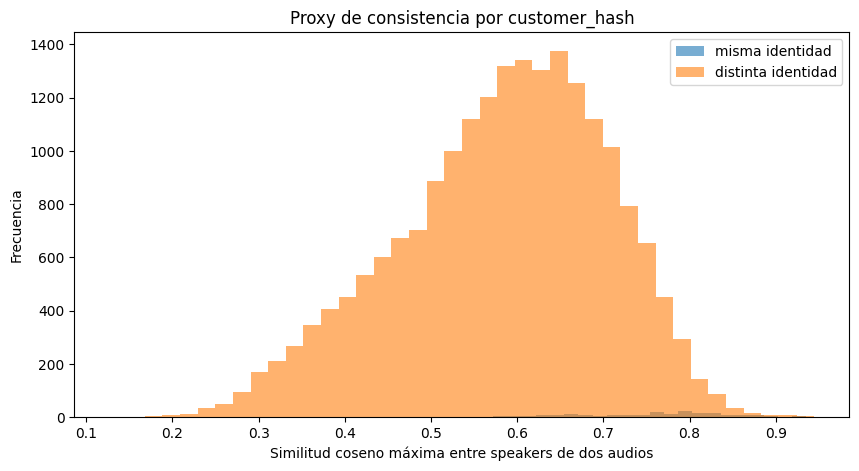

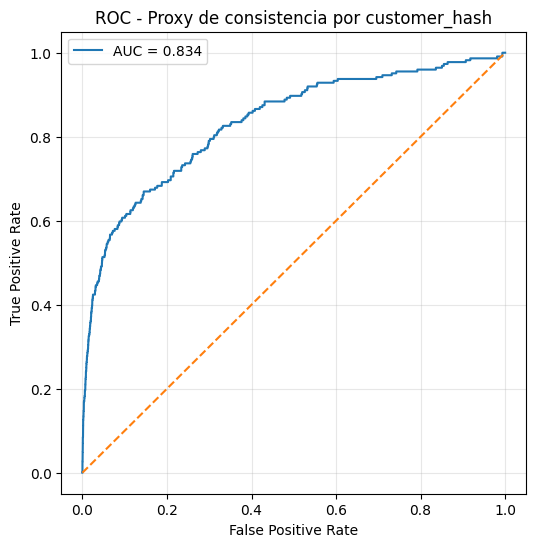

In [19]:
# =========================
# EVALUACIÓN PROXY POR CUSTOMER_HASH
# =========================

proxy_summaries = []

if not df_speaker_centroids.empty and "customer_hash" in df_speaker_centroids.columns:
    df_customer_pairs = build_proxy_pairs(
        df_centroids=df_speaker_centroids,
        identity_col="customer_hash",
        embedding_cols=embedding_cols,
        max_pairs_per_identity=MAX_PAIRS_PER_IDENTITY,
        max_negative_pairs=MAX_NEGATIVE_PAIRS
    )

    summary_customer = summarize_proxy_pairs(df_customer_pairs, "Proxy de consistencia por customer_hash")
    if summary_customer is not None:
        proxy_summaries.append(summary_customer)
else:
    df_customer_pairs = pd.DataFrame()
    print("No se puede evaluar customer_hash: faltan centroides o columna customer_hash.")


,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por agent_hash,21525,1525,20000,0.821128,0.598386,0.847077,0.61152,0.932107


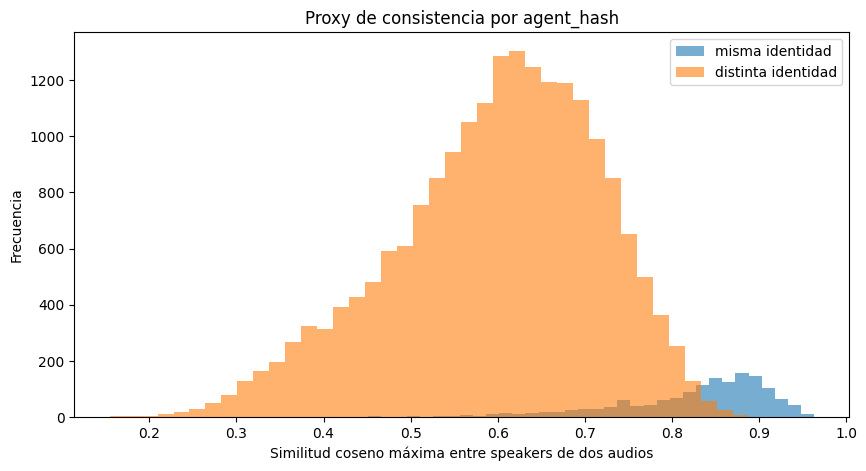

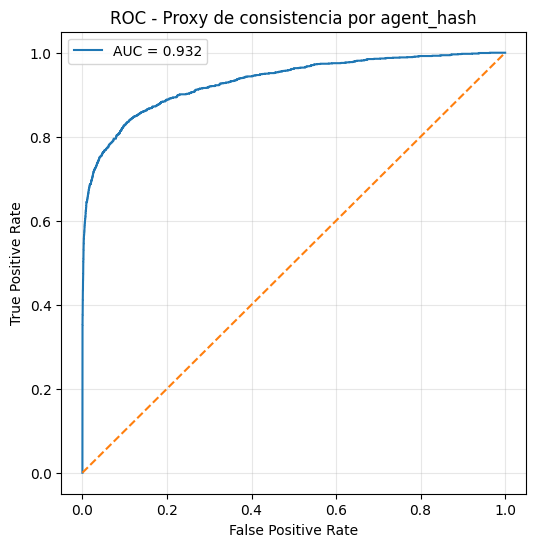

In [20]:
# =========================
# EVALUACIÓN PROXY POR AGENT_HASH
# =========================

if not df_speaker_centroids.empty and "agent_hash" in df_speaker_centroids.columns:
    df_agent_pairs = build_proxy_pairs(
        df_centroids=df_speaker_centroids,
        identity_col="agent_hash",
        embedding_cols=embedding_cols,
        max_pairs_per_identity=MAX_PAIRS_PER_IDENTITY,
        max_negative_pairs=MAX_NEGATIVE_PAIRS
    )

    summary_agent = summarize_proxy_pairs(df_agent_pairs, "Proxy de consistencia por agent_hash")
    if summary_agent is not None:
        proxy_summaries.append(summary_agent)
else:
    df_agent_pairs = pd.DataFrame()
    print("No se puede evaluar agent_hash: faltan centroides o columna agent_hash.")


In [21]:
# =========================
# TABLA FINAL DE EVALUACIÓN PROXY
# =========================

df_proxy_summary = pd.DataFrame(proxy_summaries)

if not df_proxy_summary.empty:
    display(df_proxy_summary)
else:
    print("No se generó resumen proxy.")


,evaluation,n_pairs,n_positive_pairs,n_negative_pairs,mean_similarity_positive,mean_similarity_negative,median_similarity_positive,median_similarity_negative,roc_auc
0,Proxy de consistencia por customer_hash,20224,224,20000,0.738478,0.583443,0.765404,0.595495,0.833829
1,Proxy de consistencia por agent_hash,21525,1525,20000,0.821128,0.598386,0.847077,0.611520,0.932107


## 6. Interpretación sugerida

Si la diarización y selección de anchors funcionan razonablemente, se espera que:

- las similitudes de pares con la misma identidad sean mayores que las de identidades distintas;
- el AUC sea claramente superior a 0,50;
- la separación sea más clara en `agent_hash` si los agentes tienen muchas llamadas;
- la evaluación por `customer_hash` sea más limitada si la mayoría de clientes solo tienen una llamada.

Limitación central: esta evaluación usa la mejor similitud entre speakers de dos audios porque todavía no existe un mapeo validado entre `speaker_final` y rol real cliente/agente. Cuando se consiga acceso a transcripciones segmentadas con timestamps, se podrá construir una evaluación formal de diarización con DER/JER.
